# Rep. 3. Checkpoint 1. Valuación de opciones europeas

## Eduardo Veytia Hernández

## Objetivo
Explorar cómo cambian las simulaciones de precios cuando se modifican los parámetros del modelo.

Deberás variar un parámetro a la vez, manteniendo los demás constantes (ceteris paribus) para entender cómo cada variable afecta el comportamiento del activo y el valor de la opción.

Usando el mismo activo que usamos, con los mismos parámetros usados en clase, también disponibles en Notion.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
ticker = 'SPY'
data = yf.download(ticker, start='2022-01-01', end='2026-03-10')['Close']['SPY']

[*********************100%***********************]  1 of 1 completed


In [3]:
daily_returns = data.pct_change()
daily_returns = daily_returns.dropna()
sigma = daily_returns.std() * np.sqrt(252)

In [4]:
S0 = data.iloc[-1]  # Precio spot actual
r = 0.08            # Tasa libre de riesgo
T = 100 / 365       # Tiempo al vencimiento en años
K = 580

num_simulations = 10000

In [5]:
Z = np.random.normal(0, 1, num_simulations)

In [6]:
St = S0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)

In [7]:
call = np.maximum(St - K, 0)
put = np.maximum(K - St, 0)

In [8]:
call_value = np.exp(-r * T) * np.mean(call)
put_value = np.exp(-r * T) * np.mean(put)

In [9]:
call_value, put_value

(np.float64(111.48380252553154), np.float64(0.6128841108836789))

### Parte 1 — Volatilidad
### Modificar únicamente σ.

Probar con:

- σ = 0.01
- σ = 0.10
- σ = 0.20
- σ = 0.40

### Graficar:

Distribución del precio Spot final en los 4 escenarios
### Crear:

Crear una tabla con el valor de la call para cada escenario

Crear una tabla con el valor de la put para cada escenario

In [10]:
ticker = 'SPY'
data = yf.download(ticker, start='2022-01-01', end='2026-03-10')['Close']['SPY']



daily_returns = data.pct_change()
daily_returns = daily_returns.dropna()

[*********************100%***********************]  1 of 1 completed

In [11]:
S0 = data.iloc[-1]  # Precio spot actual
r = 0.08            # Tasa libre de riesgo
T = 100 / 365       # Tiempo al vencimiento en años
K = 580
num_simulations = 10000

Z = np.random.normal(0, 1, num_simulations)

sigmas = [0.01, 0.10, 0.20, 0.40]
resultados = []

for sigma in sigmas:
    # Generar choques aleatorios
    Z = np.random.normal(0, 1, num_simulations)
    
    # Calcular precio final St para cada simulación
    St = S0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)

    call = np.maximum(St - K, 0)
    put = np.maximum(K - St, 0)

    call_value = np.exp(-r * T) * np.mean(call)
    put_value = np.exp(-r * T) * np.mean(put)

    resultados.append({
        'Sigma (σ)': sigma,
        'Call Value': round(call_value, 2),
        'Put Value': round(put_value, 2)
    })

# Mostrar resultados en una tabla
df_resultados = pd.DataFrame(resultados)
print(f"Precio Actual de {ticker} (S0): {S0:.2f}")
print(df_resultados.to_string(index=False))

Precio Actual de SPY (S0): 678.27
 Sigma (σ)  Call Value  Put Value
      0.01      110.85       0.00
      0.10      111.44       0.00
      0.20      111.49       1.27
      0.40      123.77      14.46


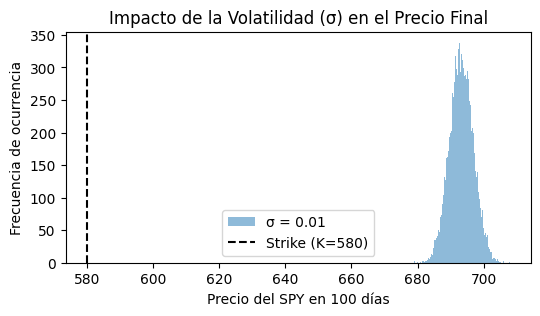

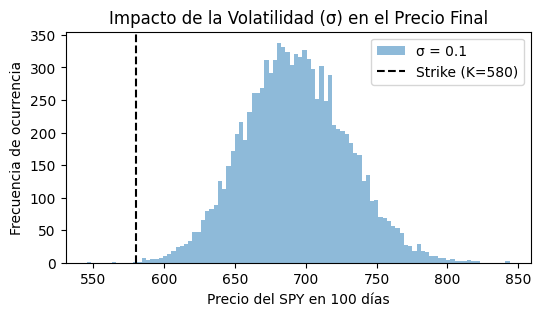

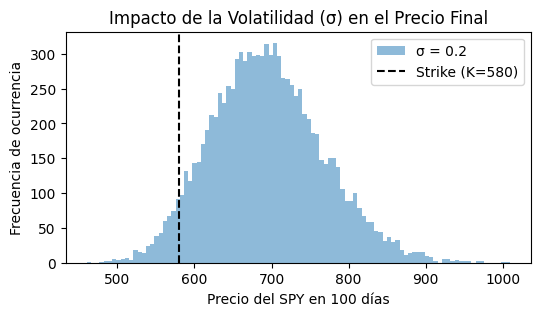

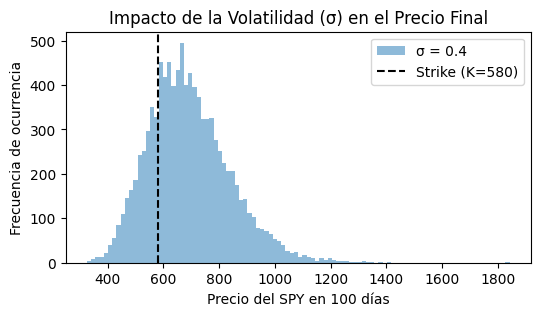

In [12]:
for s in sigmas:
    plt.figure(figsize=(6, 3))
    Z = np.random.normal(0, 1, num_simulations)
    # Fórmula de Black-Scholes para el precio final St
    St = S0 * np.exp((r - 0.5 * s**2) * T + s * np.sqrt(T) * Z)
    
    # Graficamos la distribución de cada escenario
    plt.hist(St, bins=100, alpha=0.5, label=f'σ = {s}')
    
    plt.axvline(K, color='black', linestyle='--', label=f'Strike (K={K})')
    plt.title('Impacto de la Volatilidad (σ) en el Precio Final')
    plt.xlabel('Precio del SPY en 100 días')
    plt.ylabel('Frecuencia de ocurrencia')
    plt.legend()
    plt.show()

### Preguntas
- **¿Qué sucede con la dispersión de las trayectorias?**

Cuando aumenta la volatilidad aumenta notablemente la dispersión, se abren más posibilidades para el precio y en este caso, entre más volatilidad, la distribución se aleja de la normalidad.

- **¿Cómo cambia la distribución de precios?**

El eje x se hace más grande y la distribución se sesga.

- **¿Aumenta o disminuye el valor de la opción conforme aumenta sigma?**

Aumenta.

### Actividad 2 — Tiempo al vencimiento
### Modificar únicamente T.

Probar con:

- T = 30 días
- T = 100 días
- T = 1 año

### Graficar nuevamente:

1- Distribución final del precio Spot

### Crear nuevamente

- Crear una tabla con el valor de la call para cada escenario

- Crear una tabla con el valor de la put para cada escenario

In [13]:
ticker = 'SPY'
data = yf.download(ticker, start='2022-01-01', end='2026-03-10')['Close']['SPY']



daily_returns = data.pct_change()
daily_returns = daily_returns.dropna()
sigma = daily_returns.std() * np.sqrt(252)

S0 = data.iloc[-1]  # Precio spot actual
r = 0.08            # Tasa libre de riesgo
T = 100 / 365       # Tiempo al vencimiento en años
K = 580

num_simulations = 10000

[*********************100%***********************]  1 of 1 completed


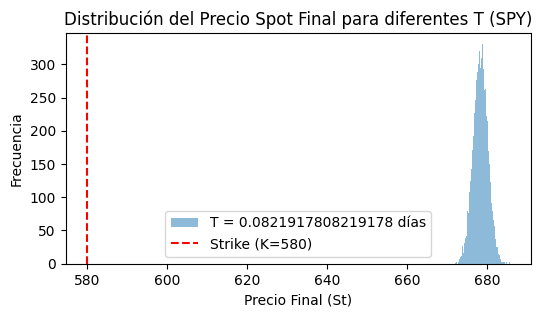

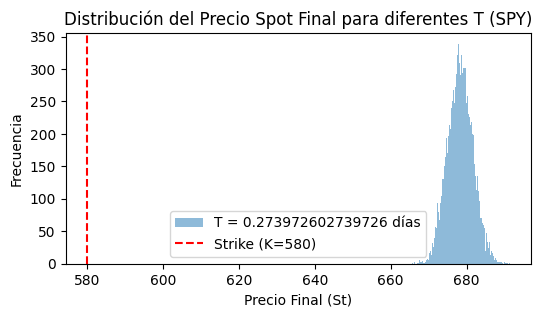

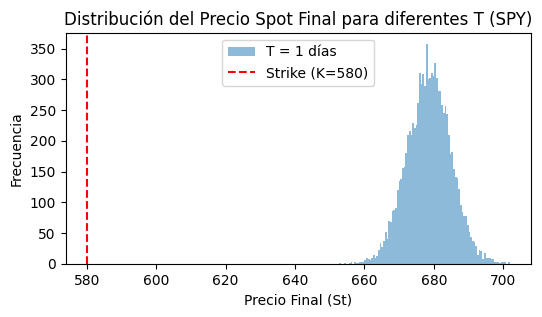

In [14]:
# --- Actividad 2: Variación de T ---
tiempos_dias = [30/365, 100/365, 1] # 30 días, 100 días, 1 año

for dias in tiempos_dias:
    plt.figure(figsize=(6, 3))
    T = dias / 365
    Z = np.random.normal(0, 1, num_simulations)
    
    # Simulación de St con el T correspondiente
    St = S0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)
    
    # Graficar distribución
    plt.hist(St, bins=100, alpha=0.5, label=f'T = {dias} días')
    plt.axvline(K, color='red', linestyle='--', label=f'Strike (K={K})')
    plt.title(f'Distribución del Precio Spot Final para diferentes T ({ticker})')
    plt.xlabel('Precio Final (St)')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.show()

### Preguntas

- **¿Cómo cambia la distribución final del precio al aumentar T?**

Muy parecido al cambio con sigma, aumenta el eje de las x y también se sesga más a la izquierda. 

- **¿Aumenta o disminuye el valor de la opción conforme aumenta sigma?**

Aumenta el valor de la opción conforme aumenta el tiempo, al ser más amplio el horizonte de tiempo, hay más incertidumbre de lo que pueda pasar, entonces el valor de tener la opción de comprar o vender, aumenta.

### Actividad 3 — Precio de ejercicio
### Modificar únicamente  K.

### Probar con:

- K = S0 * 0.70
- K = S0 * 0.90
- K = S0
- K = S0 * 1.10
- K = S0 * 1.30

### Crear:

- Crear una tabla con el valor de la call para cada escenario

- Crear una tabla con el valor de la put para cada escenario

In [15]:
ticker = 'SPY'
data = yf.download(ticker, start='2022-01-01', end='2026-03-10')['Close']['SPY']

daily_returns = data.pct_change()
daily_returns = daily_returns.dropna()
sigma = daily_returns.std() * np.sqrt(252)

S0 = data.iloc[-1]  # Precio spot actual
r = 0.08            # Tasa libre de riesgo
T = 100 / 365       # Tiempo al vencimiento en años
K = 580

num_simulations = 10000

[*********************100%***********************]  1 of 1 completed


In [16]:
strikes_pct = [0.70, 0.90, 1.00, 1.10, 1.30]
nombres = ["70%", "90%", "100%", "110%", "130%"]

Z = np.random.normal(0, 1, num_simulations)
St = S0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)

resultados_call = []
resultados_put = []

for pct, nombre in zip(strikes_pct, nombres):
    K_actual = S0 * pct

    payoff_call = np.maximum(St - K_actual, 0)
    payoff_put = np.maximum(K_actual - St, 0)
    
    v_call = np.exp(-r * T) * np.mean(payoff_call)
    v_put = np.exp(-r * T) * np.mean(payoff_put)
    
    resultados_call.append({"Escenario": nombre, "Strike (K)": round(K_actual, 2), "Call Value": round(v_call, 2)})
    resultados_put.append({"Escenario": nombre, "Strike (K)": round(K_actual, 2), "Put Value": round(v_put, 2)})

df_call = pd.DataFrame(resultados_call)
df_put = pd.DataFrame(resultados_put)

print(f"Precio Actual S0: {S0:.2f}\n")
print("TABLA DE VALORES CALL")
print(df_call.to_string(index=False))
print("\n" + "-"*30 + "\n")
print("TABLA DE VALORES PUT")
print(df_put.to_string(index=False))

Precio Actual S0: 678.27

TABLA DE VALORES CALL
Escenario  Strike (K)  Call Value
      70%      474.79      213.50
      90%      610.44       83.15
     100%      678.27       32.85
     110%      746.10        8.20
     130%      881.75        0.15

------------------------------

TABLA DE VALORES PUT
Escenario  Strike (K)  Put Value
      70%      474.79       0.00
      90%      610.44       2.36
     100%      678.27      18.43
     110%      746.10      60.13
     130%      881.75     184.79


### Preguntas

- **¿Aumenta o disminuye el valor de la opción conforme aumenta K?**

Los call values disminuten y los put values aumentan. 

- **¿Qué ocurre cuando el strike es relativamente muy alto? ¿Cuando es muy bajo?**

Se aleja muchísimo del K = S0.

### Actividad 4 — Tasa libre de riesgo
### Modificar únicamente r.

### Probar con:

- r = 0.01
- r = 0.05
- r = 0.10
### Graficar:
1- Distribución final del precio Spot

In [19]:
ticker = 'SPY'
data = yf.download(ticker, start='2022-01-01', end='2026-03-10')['Close']['SPY']

daily_returns = data.pct_change()
daily_returns = daily_returns.dropna()
sigma = daily_returns.std() * np.sqrt(252)

S0 = data.iloc[-1]  # Precio spot actual
r = 0.08            # Tasa libre de riesgo
T = 100 / 365       # Tiempo al vencimiento en años
K = 580

num_simulations = 10000

[*********************100%***********************]  1 of 1 completed


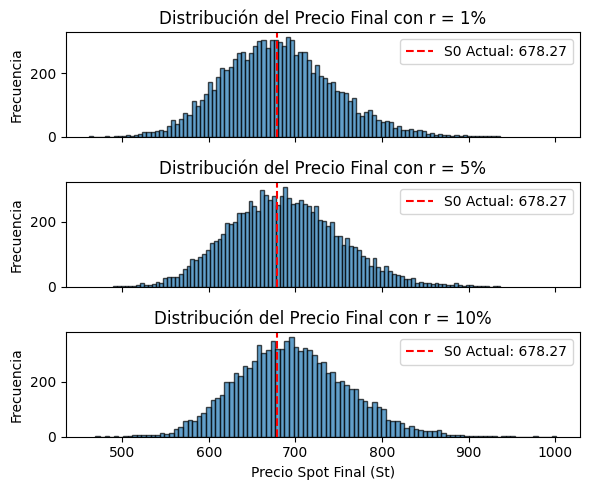

In [24]:
tasas = [0.01, 0.05, 0.10]
fig, axes = plt.subplots(3, 1, figsize=(6, 5), sharex=True)

for i, r_val in enumerate(tasas):
    # Generar simulación para cada tasa r
    Z = np.random.normal(0, 1, num_simulations)
    St = S0 * np.exp((r_val - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)
        # Graficar en el sub-eje correspondiente
    axes[i].hist(St, bins=100, alpha=0.7, edgecolor='black')
    
    # Añadir línea de referencia del precio actual S0
    axes[i].axvline(S0, color='red', linestyle='--', label=f'S0 Actual: {S0:.2f}')
    
    # Títulos y etiquetas
    axes[i].set_title(f'Distribución del Precio Final con r = {r_val*100:.0f}%', fontsize=12)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

# Configuración global
plt.xlabel('Precio Spot Final (St)')
plt.tight_layout()
plt.show()

### Preguntas

- **¿Cómo cambia el crecimiento esperado del precio del activo?**

No cambia mucho, conforme aumenta la tasa, los valores de Call aumentan, pero en las Put disminuyen.

- **¿Qué sucede con el valor de la call cuando aumenta la tasa libre de riesgo?**

Aumentan a mayor tasa.

- **¿Qué sucede con el valor de la put cuando aumenta la tasa libre de riesgo?**
|
Disminuye a mayor tasa.